In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

df = pd.read_csv('EasyVisa.csv')

In [55]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [56]:
df.drop('case_id', axis=1, inplace=True)

In [57]:
def standardize_wage(row):
    wage = row['prevailing_wage']
    unit = row['unit_of_wage']
    
    if unit == 'Hour':
        return wage * 2080  
    elif unit == 'Week':
        return wage * 52
    elif unit == 'Month':
        return wage * 12
    else: 
        return wage

df['yearly_wage'] = df.apply(standardize_wage, axis=1)

In [58]:
current_year = 2024
df['company_age'] = current_year - df['yr_of_estab']

In [59]:
df['is_certified'] = (df['case_status'] == 'Certified').astype(int)

In [60]:
edu_status = pd.crosstab(df['education_of_employee'], df['case_status'], normalize='index') * 100
print("--- Acceptance Rates by Education (%) ---")
print(edu_status, "\n")

--- Acceptance Rates by Education (%) ---
case_status            Certified     Denied
education_of_employee                      
Bachelor's             62.214188  37.785812
Doctorate              87.226277  12.773723
High School            34.035088  65.964912
Master's               78.627777  21.372223 



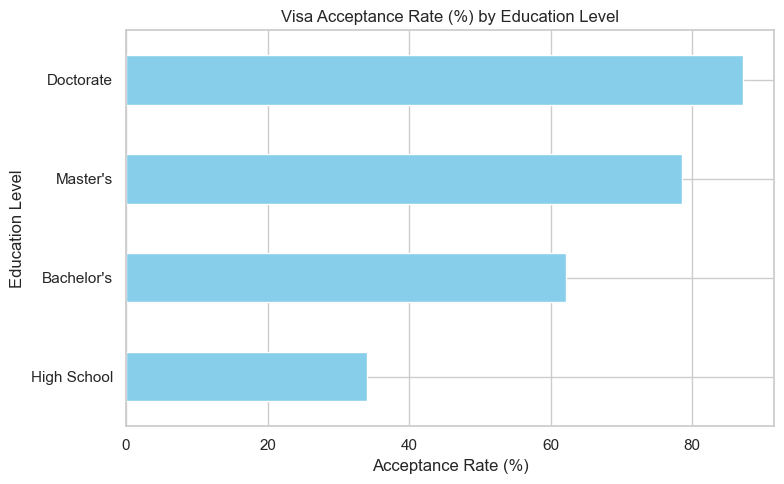

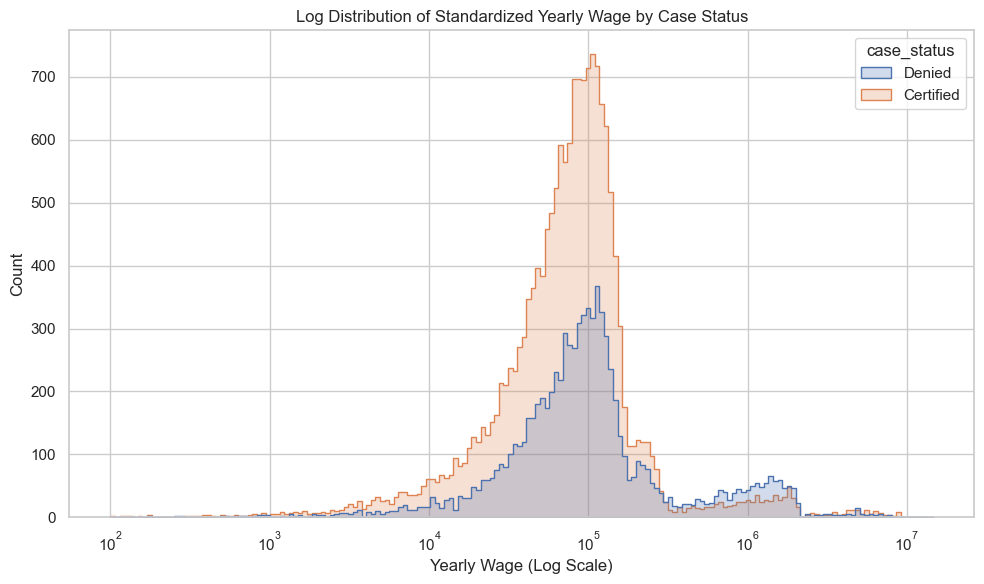

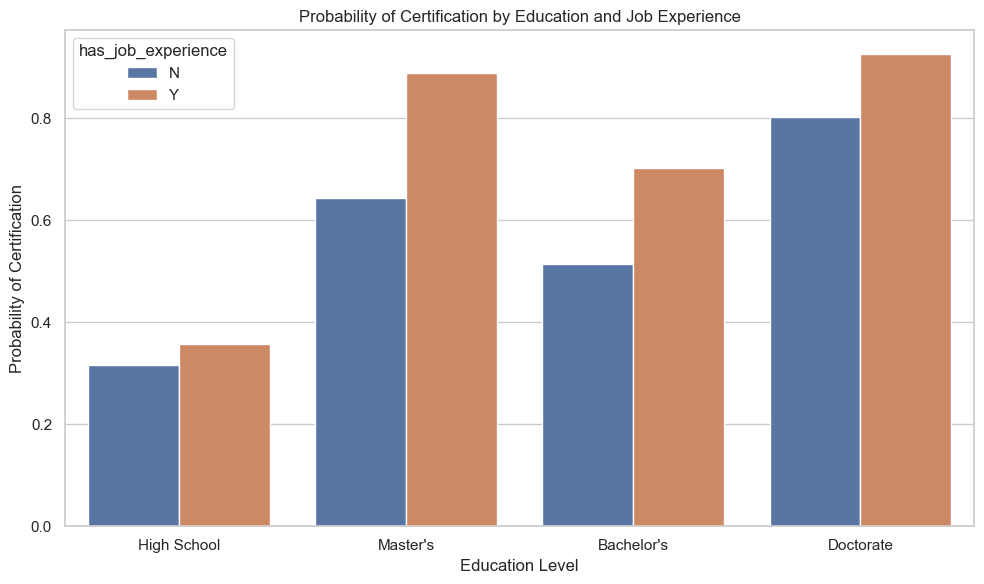

--- Chi-Square Test against Target (case_status) ---
continent:
  p-value = 8.8288e-74 | Significant Driver? Yes

education_of_employee:
  p-value = 0.0000e+00 | Significant Driver? Yes

has_job_experience:
  p-value = 1.9226e-206 | Significant Driver? Yes

requires_job_training:
  p-value = 1.8556e-01 | Significant Driver? No

region_of_employment:
  p-value = 2.3387e-63 | Significant Driver? Yes

unit_of_wage:
  p-value = 5.1934e-240 | Significant Driver? Yes

full_time_position:
  p-value = 4.4700e-02 | Significant Driver? Yes

--- Chi-Square Test for Feature Interaction ---
Education vs Experience:
  p-value = 1.8313e-01 | Are they dependent? No (They are independent)


In [9]:
sns.set_theme(style="whitegrid")

# Plot 1: Acceptance Rate by Education
plt.figure(figsize=(8, 5))
edu_status['Certified'].sort_values().plot(kind='barh', color='skyblue')
plt.title('Visa Acceptance Rate (%) by Education Level')
plt.xlabel('Acceptance Rate (%)')
plt.ylabel('Education Level')
plt.tight_layout()
plt.show()

# Plot 2: Distribution of Standardized Yearly Wage by Case Status
plt.figure(figsize=(10, 6))
# Using log_scale because wages have massive outliers
sns.histplot(data=df, x='yearly_wage', hue='case_status', log_scale=(True, False), element="step", common_norm=False)
plt.title('Log Distribution of Standardized Yearly Wage by Case Status')
plt.xlabel('Yearly Wage (Log Scale)')
plt.tight_layout()
plt.show()

# Plot 3: Multivariate Interaction (Education vs Experience vs Target)
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='education_of_employee', y='is_certified', hue='has_job_experience', errorbar=None)
plt.title('Probability of Certification by Education and Job Experience')
plt.ylabel('Probability of Certification')
plt.xlabel('Education Level')
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 5. STATISTICAL TESTING: CHI-SQUARE (Identifying Strongest Drivers)
# ---------------------------------------------------------

categorical_cols = [
    'continent', 'education_of_employee', 'has_job_experience', 
    'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position'
]

print("--- Chi-Square Test against Target (case_status) ---")
for col in categorical_cols:
    # Create a contingency table
    contingency_table = pd.crosstab(df[col], df['case_status'])
    
    # Run the Chi-Square test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    # Print the results
    is_significant = "Yes" if p < 0.05 else "No"
    print(f"{col}:")
    print(f"  p-value = {p:.4e} | Significant Driver? {is_significant}\n")

print("--- Chi-Square Test for Feature Interaction ---")
# Testing if Education and Experience interact with each other
contingency_table_interaction = pd.crosstab(df['education_of_employee'], df['has_job_experience'])
chi2_int, p_int, dof_int, expected_int = chi2_contingency(contingency_table_interaction)

is_interacting = "Yes" if p_int < 0.05 else "No (They are independent)"
print(f"Education vs Experience:\n  p-value = {p_int:.4e} | Are they dependent? {is_interacting}")

In [61]:
df['no_of_employees'] = df['no_of_employees'].abs()

In [62]:
columns_to_drop = ['prevailing_wage', 'unit_of_wage', 'yr_of_estab', 'requires_job_training']
df.drop(columns=columns_to_drop, inplace=True)

In [63]:
df.head()

,continent,education_of_employee,has_job_experience,no_of_employees,region_of_employment,full_time_position,case_status,yearly_wage,company_age,is_certified
0,Asia,High School,N,14513,West,Y,Denied,1231782.032,17,0
1,Asia,Master's,Y,2412,Northeast,Y,Certified,83425.650,22,1
2,Asia,Bachelor's,N,44444,West,Y,Denied,122996.860,16,0
3,Asia,Bachelor's,N,98,West,Y,Denied,83434.030,127,0
4,Africa,Master's,Y,1082,South,Y,Certified,149907.390,19,1


In [64]:
binary_cols = ['has_job_experience', 'full_time_position']
for col in binary_cols:
    df[col] = df[col].map({'Y': 1, 'N': 0})

In [65]:
education_map = {
    'High School': 0,
    "Bachelor's": 1,
    "Master's": 2,
    'Doctorate': 3
}
df['education_of_employee'] = df['education_of_employee'].map(education_map)

In [66]:
df = pd.get_dummies(df, columns=['continent', 'region_of_employment'], drop_first=True)

In [67]:
df.head()

,education_of_employee,has_job_experience,no_of_employees,full_time_position,case_status,yearly_wage,company_age,is_certified,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West
0,0,0,14513,1,Denied,1231782.032,17,0,True,False,False,False,False,False,False,False,True
1,2,1,2412,1,Certified,83425.650,22,1,True,False,False,False,False,False,True,False,False
2,1,0,44444,1,Denied,122996.860,16,0,True,False,False,False,False,False,False,False,True
3,1,0,98,1,Denied,83434.030,127,0,True,False,False,False,False,False,False,False,True
4,2,1,1082,1,Certified,149907.390,19,1,False,False,False,False,False,False,False,True,False


In [68]:
df.drop(columns=['case_status'], inplace=True)

In [69]:
df.head()

,education_of_employee,has_job_experience,no_of_employees,full_time_position,yearly_wage,company_age,is_certified,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West
0,0,0,14513,1,1231782.032,17,0,True,False,False,False,False,False,False,False,True
1,2,1,2412,1,83425.650,22,1,True,False,False,False,False,False,True,False,False
2,1,0,44444,1,122996.860,16,0,True,False,False,False,False,False,False,False,True
3,1,0,98,1,83434.030,127,0,True,False,False,False,False,False,False,False,True
4,2,1,1082,1,149907.390,19,1,False,False,False,False,False,False,False,True,False


In [70]:
true_cols = ['continent_Europe', 'continent_Asia', 'continent_North America', 'continent_Oceania','continent_South America','region_of_employment_Midwest','region_of_employment_South','region_of_employment_West','region_of_employment_Northeast']
for col in true_cols:
    df[col] = df[col].map({True: 1, False: 0})

In [71]:
df.head()

,education_of_employee,has_job_experience,no_of_employees,full_time_position,yearly_wage,company_age,is_certified,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West
0,0,0,14513,1,1231782.032,17,0,1,0,0,0,0,0,0,0,1
1,2,1,2412,1,83425.650,22,1,1,0,0,0,0,0,1,0,0
2,1,0,44444,1,122996.860,16,0,1,0,0,0,0,0,0,0,1
3,1,0,98,1,83434.030,127,0,1,0,0,0,0,0,0,0,1
4,2,1,1082,1,149907.390,19,1,0,0,0,0,0,0,0,1,0


In [72]:
from sklearn.model_selection import train_test_split
X = df.drop('is_certified', axis=1)
y = df['is_certified']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [73]:
cols_to_scale = ['no_of_employees', 'yearly_wage', 'company_age']

In [74]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [75]:
print(f"X_train Shape (After Preprocessing): {X_train.shape}")
print(f"X_test Shape (After Preprocessing): {X_test.shape}")

X_train Shape (After Preprocessing): (20384, 15)
X_test Shape (After Preprocessing): (5096, 15)


In [76]:
X_train.head()

,education_of_employee,has_job_experience,no_of_employees,full_time_position,yearly_wage,company_age,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West
3516,1,1,-0.065228,1,-0.234224,-0.111487,1,0,0,0,0,0,0,1,0
13759,1,1,-0.111943,1,-0.275770,0.430616,1,0,0,0,0,1,0,0,0
6019,1,0,-0.213270,1,0.016080,0.194919,0,0,1,0,0,0,0,1,0
779,2,1,-0.197118,1,-0.259187,0.265629,1,0,0,0,0,0,1,0,0
22792,1,1,-0.211262,1,-0.186793,0.006362,0,0,1,0,0,0,0,0,1


In [33]:
from sklearn.linear_model import LogisticRegression  
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,roc_curve, accuracy_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [34]:
def evaluate(y_test,y_pred):
    acc =  accuracy_score(y_test, y_pred)
    roc_score = roc_auc_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)   
    return acc, roc_score, prec, rec, f1

In [35]:
models = {
    "Logistic Regression":LogisticRegression(),
    "K-Nearest Neighbors":KNeighborsClassifier(),
    "Random Forest":RandomForestClassifier(),
    "Decision Tree":DecisionTreeClassifier(),
    "SVM":SVC(),
    "Gradient Boosting":GradientBoostingClassifier(),
    "AdaBoost":AdaBoostClassifier(),
    "XGBoost":XGBClassifier(),
    "CatBoost":CatBoostClassifier(verbose=False)
}

In [85]:
def evaluate_models(X_train, y_train, X_test, y_test, models):
    models_list = []
    f1_list = []
    auc= []
    
    for i in range(len(list(models))):
        model = list(models.values())[i]
        model.fit(X_train, y_train) 

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Training set performance
        model_train_accuracy, model_train_rocauc_score, model_train_precision, model_train_recall, model_train_f1=evaluate(y_train ,y_train_pred)


        # Test set performance
        model_test_accuracy, model_test_rocauc_score, model_test_precision, model_test_recall, model_test_f1=evaluate(y_test ,y_test_pred)
        
        print(list(models.keys())[i])
        models_list.append(list(models.keys())[i])

        print('Model performance for Training set')
        print("- Accuracy: {:.4f}".format(model_train_accuracy))
        print('- F1 score: {:.4f}'.format(model_train_f1)) 
        print('- Precision: {:.4f}'.format(model_train_precision))
        print('- Recall: {:.4f}'.format(model_train_recall))
        print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

        print('----------------------------------')

        print('Model performance for Test set')
        print('- Accuracy: {:.4f}'.format(model_test_accuracy))
        f1_list.append(model_test_f1)
        print('- F1 score: {:.4f}'.format(model_test_f1))
        print('- Precision: {:.4f}'.format(model_test_precision))
        print('- Recall: {:.4f}'.format(model_test_recall))
        print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))
        auc.append(model_test_rocauc_score)
        print('='*35)
        print('\n')
        
    report=pd.DataFrame(list(zip(models_list, f1_list)), columns=['Model Name', 'f1 score']).sort_values(by=['f1 score'], ascending=False)
        
    return report


In [80]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42,sampling_strategy='minority')
X_res, y_res = smote.fit_resample(X_train, y_train)


In [86]:
smote_model_report =evaluate_models(X_res, y_res, X_test, y_test, models)

Logistic Regression
Model performance for Training set
- Accuracy: 0.6878
- F1 score: 0.6726
- Precision: 0.7070
- Recall: 0.6415
- Roc Auc Score: 0.6878
----------------------------------
Model performance for Test set
- Accuracy: 0.6617
- F1 score: 0.7156
- Precision: 0.8160
- Recall: 0.6372
- Roc Auc Score: 0.6741


K-Nearest Neighbors
Model performance for Training set
- Accuracy: 0.8245
- F1 score: 0.8147
- Precision: 0.8629
- Recall: 0.7716
- Roc Auc Score: 0.8245
----------------------------------
Model performance for Test set
- Accuracy: 0.6637
- F1 score: 0.7305
- Precision: 0.7859
- Recall: 0.6824
- Roc Auc Score: 0.6542


Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.6803
- F1 score: 0.7524
- Precision: 0.7795
- Recall: 0.7271
- Roc Auc Score: 0.6567


Decision Tree
Model performance for Trainin

In [82]:
base_model_report =evaluate_models(X_train, y_train, X_test, y_test, models)

Logistic Regression
Model performance for Training set
- Accuracy: 0.7231
- F1 score: 0.8106
- Precision: 0.7460
- Recall: 0.8875
- Roc Auc Score: 0.6400
----------------------------------
Model performance for Test set
- Accuracy: 0.7131
- F1 score: 0.8037
- Precision: 0.7401
- Recall: 0.8793
- Roc Auc Score: 0.6291


K-Nearest Neighbors
Model performance for Training set
- Accuracy: 0.7956
- F1 score: 0.8528
- Precision: 0.8217
- Recall: 0.8864
- Roc Auc Score: 0.7498
----------------------------------
Model performance for Test set
- Accuracy: 0.7070
- F1 score: 0.7883
- Precision: 0.7619
- Recall: 0.8167
- Roc Auc Score: 0.6515


Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.7151
- F1 score: 0.7955
- Precision: 0.7641
- Recall: 0.8296
- Roc Auc Score: 0.6571


Decision Tree
Model performance for Trainin

In [83]:
base_model_report

,Model Name,Accuracy
4,SVM,0.734498
5,Gradient Boosting,0.734301
8,CatBoost,0.732535
6,AdaBoost,0.724294
7,XGBoost,0.720761
2,Random Forest,0.715071
0,Logistic Regression,0.713108
1,K-Nearest Neighbors,0.707025
3,Decision Tree,0.650314


In [87]:
smote_model_report

,Model Name,f1 score
8,CatBoost,0.794771
4,SVM,0.769678
7,XGBoost,0.768380
5,Gradient Boosting,0.754830
2,Random Forest,0.752394
6,AdaBoost,0.742983
1,K-Nearest Neighbors,0.730503
3,Decision Tree,0.717057
0,Logistic Regression,0.715605


In [89]:
import optuna

from sklearn.metrics import f1_score

def objective(trial):
    param = {
        'iterations': trial.suggest_int('iterations', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 8), 
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-3, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'eval_metric': 'F1',
        'verbose': False,
        'random_seed': 42,
    }

    cat = CatBoostClassifier(**param)
    
    cat.fit(
        X_res, y_res,
        eval_set=[(X_test, y_test)], 
        early_stopping_rounds=50,    
        verbose=False
    )
    
    preds = cat.predict(X_test)
    return f1_score(y_test, preds)

print("Starting High-Speed Optuna Optimization...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("\n--- Best F1 Score ---")
print(study.best_value)
print("\n--- Best Parameters ---")
print(study.best_params)

best_catboost = CatBoostClassifier(**study.best_params, verbose=False)

best_catboost.fit(
    X_res, y_res,
    eval_set=[(X_test, y_test)], 
    early_stopping_rounds=50,
    verbose=False
)


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("\n--- Best F1 Score ---")
print(study.best_value)
print("\n--- Best Parameters ---")
print(study.best_params)

best_catboost = CatBoostClassifier(**study.best_params, verbose=False)
best_catboost.fit(X_res, y_res)

[I 2026-03-03 12:34:18,532] A new study created in memory with name: no-name-be99be0f-acf0-437a-81f7-71ec1e633a26


Starting High-Speed Optuna Optimization...


[I 2026-03-03 12:34:21,633] Trial 0 finished with value: 0.7888317413666421 and parameters: {'iterations': 944, 'learning_rate': 0.16125184437412837, 'depth': 4, 'l2_leaf_reg': 0.045622313094855795, 'random_strength': 1.0808806533375788, 'bagging_temperature': 0.6266927152651582, 'border_count': 208}. Best is trial 0 with value: 0.7888317413666421.
[I 2026-03-03 12:34:26,262] Trial 1 finished with value: 0.7895278717458449 and parameters: {'iterations': 436, 'learning_rate': 0.08006280141375649, 'depth': 5, 'l2_leaf_reg': 0.06263803423426986, 'random_strength': 0.0028445008834583224, 'bagging_temperature': 0.4957283270218238, 'border_count': 102}. Best is trial 1 with value: 0.7895278717458449.
[I 2026-03-03 12:34:27,637] Trial 2 finished with value: 0.7787637238682509 and parameters: {'iterations': 357, 'learning_rate': 0.0857635714524204, 'depth': 8, 'l2_leaf_reg': 0.15170364373406164, 'random_strength': 0.01710336567822398, 'bagging_temperature': 0.39068562747829616, 'border_count':


--- Best F1 Score ---
0.799305455071625

--- Best Parameters ---
{'iterations': 410, 'learning_rate': 0.2413210961254006, 'depth': 7, 'l2_leaf_reg': 0.003619495089193769, 'random_strength': 0.0019574350528403176, 'bagging_temperature': 0.3308310657510184, 'border_count': 208}


[I 2026-03-03 12:37:10,273] A new study created in memory with name: no-name-100c59a5-e5a9-40bf-be5b-9f5ec8a68429
[I 2026-03-03 12:37:11,846] Trial 0 finished with value: 0.7666872682323856 and parameters: {'iterations': 465, 'learning_rate': 0.09771051651423404, 'depth': 8, 'l2_leaf_reg': 0.001034657960746678, 'random_strength': 4.012772196893342, 'bagging_temperature': 0.3516046680080379, 'border_count': 182}. Best is trial 0 with value: 0.7666872682323856.
[I 2026-03-03 12:37:13,298] Trial 1 finished with value: 0.7622453739698336 and parameters: {'iterations': 926, 'learning_rate': 0.09886153322223497, 'depth': 5, 'l2_leaf_reg': 0.03864892284314719, 'random_strength': 4.016431921314762, 'bagging_temperature': 0.37599829219677194, 'border_count': 238}. Best is trial 0 with value: 0.7666872682323856.
[I 2026-03-03 12:37:14,767] Trial 2 finished with value: 0.7787637238682509 and parameters: {'iterations': 869, 'learning_rate': 0.05793143347918591, 'depth': 8, 'l2_leaf_reg': 0.0383558


--- Best F1 Score ---
0.7982049797336421

--- Best Parameters ---
{'iterations': 985, 'learning_rate': 0.11228777604058679, 'depth': 8, 'l2_leaf_reg': 0.02187037560767319, 'random_strength': 0.005558068957260384, 'bagging_temperature': 0.9114836208045363, 'border_count': 221}


CatBoostClassifier(bagging_temperature=0.9114836208045363, border_count=221, depth=8, iterations=985, l2_leaf_reg=0.02187037560767319, learning_rate=0.11228777604058679, random_strength=0.005558068957260384, verbose=False)

<Axes: >

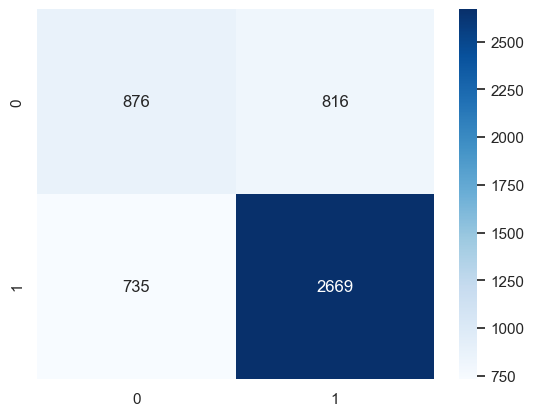

In [90]:
cm = confusion_matrix(y_test, best_catboost.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

In [91]:
cr = classification_report(y_test, best_catboost.predict(X_test))
print(cr)

              precision    recall  f1-score   support

           0       0.54      0.52      0.53      1692
           1       0.77      0.78      0.77      3404

    accuracy                           0.70      5096
   macro avg       0.65      0.65      0.65      5096
weighted avg       0.69      0.70      0.69      5096

